<a href="https://colab.research.google.com/github/MostaryKhatun/stress-depression-biomarker-discovery/blob/main/DataPreprocess_Combat_Correction_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data_Preprocessing


 STEP 1: Upload the Files

In [1]:
from google.colab import files
uploaded = files.upload()


Saving GSE63878_deg.txt to GSE63878_deg.txt
Saving GSE63878_series_matrix.txt to GSE63878_series_matrix.txt
Saving target.csv to target.csv


In [2]:
from google.colab import files
uploaded = files.upload()


Saving GSE98793_deg.txt to GSE98793_deg.txt
Saving GSE98793_series_matrix.txt to GSE98793_series_matrix.txt
Saving Target.csv to Target.csv


In [70]:
from google.colab import files
uploaded = files.upload()

Saving target.csv to target.csv


In [71]:
import os
import csv
import numpy as np
import pandas as pd


Covert test to csv

In [72]:
def convert_txt_to_csv(input_file, output_file, delimiter='\t'):
    """
    Converts a text file to a CSV file.

    Parameters:
    - input_file (str): Path to the input text file.
    - output_file (str): Path to the output CSV file.
    - delimiter (str): Delimiter used in the input text file (default is tab-delimited).
    """
    try:
        with open(input_file, 'r', newline='') as infile:
            reader = csv.reader(infile, delimiter=delimiter)
            with open(output_file, 'w', newline='') as outfile:
                writer = csv.writer(outfile)
                for row in reader:
                    writer.writerow(row)
        print(f"File '{input_file}' has been successfully converted to '{output_file}'.")
    except Exception as e:
        print(f"An error occurred while converting '{input_file}': {e}")

copy adj.p.value gene

In [73]:
def merge_csv_files(
    first_csv_path,
    second_csv_path,
    output_csv_path,
    first_key_column,
    second_key_column,
    columns_to_copy,
    delimiter=','
):
    # Check if input files exist
    if not os.path.isfile(first_csv_path):
        print(f"Error: The file '{first_csv_path}' does not exist.")
        return
    if not os.path.isfile(second_csv_path):
        print(f"Error: The file '{second_csv_path}' does not exist.")
        return

    # Read the first CSV and create a mapping from key to desired columns
    first_data = {}
    try:
        with open(first_csv_path, 'r', newline='', encoding='utf-8') as first_file:
            reader = csv.DictReader(first_file, delimiter=delimiter)
            if first_key_column not in reader.fieldnames:
                print(f"Error: '{first_key_column}' not found in the first CSV file headers.")
                return
            for row in reader:
                key = row.get(first_key_column)
                if key is None:
                    continue
                extracted = {col: row.get(col, "") for col in columns_to_copy}
                first_data[key] = extracted
    except Exception as e:
        print(f"Error reading '{first_csv_path}': {e}")
        return

    # Read the second CSV and merge data
    try:
        with open(second_csv_path, 'r', newline='', encoding='utf-8') as second_file, \
             open(output_csv_path, 'w', newline='', encoding='utf-8') as output_file:

            reader = csv.DictReader(second_file, delimiter=delimiter)
            second_fieldnames = reader.fieldnames
            if second_fieldnames is None:
                print(f"Error: The second CSV file '{second_csv_path}' is empty or missing headers.")
                return
            if second_key_column not in second_fieldnames:
                print(f"Error: '{second_key_column}' not found in the second CSV file headers.")
                return

            # Insert new columns after the first column
            insert_position = 1
            new_fieldnames = second_fieldnames[:insert_position] + columns_to_copy + second_fieldnames[insert_position:]
            writer = csv.DictWriter(output_file, fieldnames=new_fieldnames, delimiter=delimiter)
            writer.writeheader()

            for row in reader:
                key = row.get(second_key_column)
                if key is None:
                    writer.writerow(row)
                    continue

                additional_data = first_data.get(key, {col: "" for col in columns_to_copy})
                new_row = {**row}
                # Insert additional_data after the first column
                for col in columns_to_copy:
                    new_row[col] = additional_data.get(col, "")
                # Ensure the order of columns
                ordered_row = {field: new_row.get(field, "") for field in new_fieldnames}
                writer.writerow(ordered_row)

    except Exception as e:
        print(f"Error processing files: {e}")
        return

    print(f"Files have been successfully merged into '{output_csv_path}'.")

perform system biology:Gene regularator network

In [75]:
def perform_analysis(file_path, output_cleaned_file, report_file):
    """
    Performs data analysis on the given CSV file.

    Parameters:
    - file_path (str): Path to the input CSV file.
    - output_cleaned_file (str): Path to save the cleaned filtered data.
    - report_file (str): Path to save the analysis report.
    """
    data = pd.read_csv(file_path)

    # Get the number of columns and rows
    num_columns = data.shape[1]
    num_rows = data.shape[0]

    # Print column names
    column_names = data.columns.tolist()
    print("Column Names:")
    for col in column_names:
        print(f"- {col}")

    # Take column name and threshold as input from the user
    column_name = input("Enter the column name for analysis: ").strip()
    if column_name not in column_names:
        print(f"Error: Column '{column_name}' does not exist in the data.")
        return

    # Calculate statistics for the column
    mean_value = data[column_name].mean()
    median_value = data[column_name].median()
    mode_value = data[column_name].mode()[0] if not data[column_name].mode().empty else None
    std_dev = data[column_name].std()
    min_value = data[column_name].min()
    max_value = data[column_name].max()

    print(f"Mean: {mean_value}\nMax: {max_value}")

    try:
        threshold = float(input("Enter the threshold value: ").strip())
    except ValueError:
        print("Invalid threshold value.")
        return

    # Filter the data based on the input threshold
    filtered_data = data[data[column_name] < threshold]
    filtered_num_rows = filtered_data.shape[0]

    # Identify and remove rows with any blank (NaN) values
    blank_rows = filtered_data[filtered_data.isna().any(axis=1)].shape[0]
    filtered_data_cleaned = filtered_data.dropna()

    # Save the cleaned filtered data to a new CSV file
    filtered_data_cleaned.to_csv(output_cleaned_file, index=False)

    # Generate a report and save it to a text file
    report = f"""
CSV File Analysis Report
------------------------

Number of Columns: {num_columns}
Number of Rows: {num_rows}

Column Names:
{', '.join(column_names)}

Selected Column: {column_name}

Statistics for {column_name}:
- Mean: {mean_value}
- Median: {median_value}
- Mode: {mode_value}
- Standard Deviation: {std_dev}
- Minimum: {min_value}
- Maximum: {max_value}

Filtering Data:
- Threshold: {threshold}
- Rows after filtering: {filtered_num_rows}

Blank Rows:
- Number of Rows with Blanks: {blank_rows}
- Total Rows after removing blank rows: {filtered_data_cleaned.shape[0]}

Cleaned Filtered Data saved to: {output_cleaned_file}
"""
    with open(report_file, 'w') as report_f:
        report_f.write(report)

    print(f"Report generated and saved to '{report_file}'")
    print(f"Cleaned data saved to '{output_cleaned_file}'")

Transpose Matrix

In [76]:
def transpose_data(input_file, output_file):
    """
    Transposes the data from the input CSV file after removing the first three columns.

    Parameters:
    - input_file (str): Path to the input CSV file.
    - output_file (str): Path to save the transposed data.
    """
    data = pd.read_csv(input_file)
    # Remove the first three columns
    data = data.iloc[:, 3:]
    # Transpose the DataFrame
    transposed_data = data.T
    # Save the transposed DataFrame
    transposed_data.to_csv(output_file, header=False, index=True)
    print(f"Transposed data saved to '{output_file}'")

Adding the lavel

In [77]:
def add_target_column(transposed_file, target_file, output_file):
    """
    Adds a 'target' column to the transposed data based on the target genes.

    Parameters:
    - transposed_file (str): Path to the transposed CSV file.
    - target_file (str): Path to the CSV file containing target genes.
    - output_file (str): Path to save the labeled data.
    """
    # Load the transposed data
    df_transposed = pd.read_csv(transposed_file)
    # Load the target genes
    target_genes = pd.read_csv(target_file, header=None, names=['Gene.symbol'])['Gene.symbol'].str.strip()
    # Add a 'target' column initialized to 1
    df_transposed['target'] = 1
    # Remove leading/trailing spaces from 'Gene.symbol'
    df_transposed['Gene.symbol'] = df_transposed['Gene.symbol'].str.strip()
    # Update 'target' to 0 where 'Gene.symbol' matches any value in target_genes
    df_transposed.loc[df_transposed['Gene.symbol'].isin(target_genes), 'target'] = 0
    # Remove the 'Gene.symbol' column
    df_transposed = df_transposed.iloc[:, 1:]
    # Save the updated DataFrame
    df_transposed.to_csv(output_file, index=False)
    print(f"Labeled data saved to '{output_file}'")

main

In [78]:
# Dynamic dataset name
dataset_name = input("Enter the dataset name (e.g., 'GSE62792'): ").strip()

Enter the dataset name (e.g., 'GSE62792'): GSE98793


In [79]:
# File paths
deg_input_file = f'{dataset_name}_deg.txt'
metrix_input_file = f'{dataset_name}_series_matrix.txt'
deg_output_file = f'{dataset_name}_deg.csv'
metrix_output_file = f'{dataset_name}_series_matrix.csv'
merged_output_file = f'{dataset_name}_series_matrix_with_pvalues.csv'
cleaned_file_path = f'filtered_data_{dataset_name}.csv'
report_file_path = f'analysis_report_{dataset_name}.txt'
transposed_file = f'{dataset_name}_matrix_Transpose.csv'
labeled_output_file = f'{dataset_name}_matrix_Transpose_labeled.csv'
target_file = 'target.csv'  # Ensure this file exists in your working directory

In [80]:
# Step 1: Convert text files to CSV
convert_txt_to_csv(deg_input_file, deg_output_file)
convert_txt_to_csv(metrix_input_file, metrix_output_file)

File 'GSE98793_deg.txt' has been successfully converted to 'GSE98793_deg.csv'.
File 'GSE98793_series_matrix.txt' has been successfully converted to 'GSE98793_series_matrix.csv'.


In [81]:
# Step 2: Merge CSV files
merge_csv_files(
    first_csv_path=deg_output_file,
    second_csv_path=metrix_output_file,
    output_csv_path=merged_output_file,
    first_key_column='ID',
    second_key_column='ID_REF',
    columns_to_copy=['adj.P.Val', 'P.Value', 'Gene.symbol'],
    delimiter=','
)

Files have been successfully merged into 'GSE98793_series_matrix_with_pvalues.csv'.


In [82]:
# Step 3: Perform data analysis
perform_analysis(
    file_path=merged_output_file,
    output_cleaned_file=cleaned_file_path,
    report_file=report_file_path
)

Column Names:
- ID_REF
- adj.P.Val
- P.Value
- Gene.symbol
- GSM2612096
- GSM2612097
- GSM2612098
- GSM2612099
- GSM2612100
- GSM2612101
- GSM2612102
- GSM2612103
- GSM2612104
- GSM2612105
- GSM2612106
- GSM2612107
- GSM2612108
- GSM2612109
- GSM2612110
- GSM2612111
- GSM2612112
- GSM2612113
- GSM2612114
- GSM2612115
- GSM2612116
- GSM2612117
- GSM2612118
- GSM2612119
- GSM2612120
- GSM2612121
- GSM2612122
- GSM2612123
- GSM2612124
- GSM2612125
- GSM2612126
- GSM2612127
- GSM2612128
- GSM2612129
- GSM2612130
- GSM2612131
- GSM2612132
- GSM2612133
- GSM2612134
- GSM2612135
- GSM2612136
- GSM2612137
- GSM2612138
- GSM2612139
- GSM2612140
- GSM2612141
- GSM2612142
- GSM2612143
- GSM2612144
- GSM2612145
- GSM2612146
- GSM2612147
- GSM2612148
- GSM2612149
- GSM2612150
- GSM2612151
- GSM2612152
- GSM2612153
- GSM2612154
- GSM2612155
- GSM2612156
- GSM2612157
- GSM2612158
- GSM2612159
- GSM2612160
- GSM2612161
- GSM2612162
- GSM2612163
- GSM2612164
- GSM2612165
- GSM2612166
- GSM2612167
- GSM

In [83]:
# Step 4: Transpose the data
transpose_data(
    input_file=cleaned_file_path,
    output_file=transposed_file
)

Transposed data saved to 'GSE98793_matrix_Transpose.csv'


In [84]:
# Step 5: Add the target column
add_target_column(
    transposed_file=transposed_file,
    target_file=target_file,
    output_file=labeled_output_file
)

Labeled data saved to 'GSE98793_matrix_Transpose_labeled.csv'


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#0.05_Combat_correction

In [26]:
# ==========================================
# Step 2: Import
# ==========================================
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad

# ==========================================
# Step 3: Load datasets
# ==========================================
base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection"

train_files = [
    "GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv",
    "GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
]

# ==========================================
# Step 4: Load + merge datasets
# ==========================================
dfs = []

for file in train_files:
    df = pd.read_csv(f"{base_path}/{file}")
    df.columns = df.columns.str.strip()

    df["Batch"] = file
    dfs.append(df)

combined_df = pd.concat(dfs, axis=0, ignore_index=True)

print("Combined shape:", combined_df.shape)

# ==========================================
# VERY IMPORTANT STEP
# Separate target BEFORE ComBat
# ==========================================
y = combined_df["target"].astype(int)   # preserve 0/1
batch = combined_df["Batch"]

# Expression matrix only
X = combined_df.drop(columns=["target", "Batch"])

# Numeric conversion
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

# ==========================================
# Step 5: ComBat correction
# ==========================================
adata = ad.AnnData(X)
adata.obs["batch"] = batch.values

sc.pp.combat(adata, key="batch")

X_corrected = pd.DataFrame(
    adata.X,
    columns=X.columns
)

print("Batch correction done!")

# ==========================================
# Step 6: Reattach target
# ==========================================
final_df = X_corrected.copy()
final_df["target"] = y.values
final_df["Batch"] = batch.values

print("Final shape:", final_df.shape)

# ==========================================
# Step 7: Save file
# ==========================================
output_path = base_path + "/combined_combat_corrected.csv"

final_df.to_csv(output_path, index=False)

print("Saved successfully!")

/tmp/ipykernel_31152/1989837115.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Batch"] = file
/tmp/ipykernel_31152/1989837115.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Batch"] = file


Combined shape: (288, 1287)
X shape: (288, 1285)
Target distribution:
target
1    176
0    112
Name: count, dtype: int64


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_combat.py:349: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


Batch correction done!
Final shape: (288, 1287)
Saved successfully!


#Common_gene

In [28]:
import pandas as pd
import os

# =========================
# FUNCTION (MUST RUN FIRST)
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)

    # clean column names
    df.columns = df.columns.str.strip()

    # get all columns except target
    genes = (
        pd.Index(df.columns)
        .str.upper()
        .str.strip()
    )

    # remove Sample and target columns if present
    genes = genes.difference(["SAMPLE", "TARGET"])

    return set(genes)


# =========================
# COMMON GENE PIPELINE
# =========================
base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection"

# datasets = [
#     "GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv",
#     "GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
# ]

datasets = [
    "GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv",
    "GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
]


gene_sets = []

for ds in datasets:
    path = os.path.join(base_path, ds)

    genes = get_gene_set(path)

    print(ds, "genes:", len(genes))
    gene_sets.append(genes)

# =========================
# FIND COMMON GENES
# =========================
common_genes = set.intersection(*gene_sets)

print("\n✅ FINAL COMMON GENES:", len(common_genes))

# =========================
# SAVE COMMON GENES
# =========================
common_genes_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Gene.symbol"]
)

output_file = os.path.join(base_path, "Common_Genes.csv")
common_genes_df.to_csv(output_file, index=False)

print("✅ Common genes saved to:", output_file)

GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv genes: 496
GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv genes: 800

✅ FINAL COMMON GENES: 11
✅ Common genes saved to: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection/Common_Genes.csv


In [29]:
import pandas as pd


# ==========================================================
# File paths
# ==========================================================

base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection"


GSE63878_file = (
    f"{base_path}/GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
)


GSE98793_file = (
    f"{base_path}/GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
)



# ==========================================================
# Load datasets
# ==========================================================


GSE63878_df = pd.read_csv(
    GSE63878_file
)


GSE98793_df = pd.read_csv(
    GSE98793_file
)



# ==========================================================
# Extract gene sets
# (last column is target/class, exclude it)
# ==========================================================


top1000_GSE63878 = set(
    GSE63878_df.columns[:-1]
)


top1000_GSE98793 = set(
    GSE98793_df.columns[:-1]
)



# ==========================================================
# Common genes
# ==========================================================


common_genes = list(
    top1000_GSE63878
    .intersection(top1000_GSE98793)
)



# ==========================================================
# Result
# ==========================================================


print(
    "Number of Common Genes =",
    len(common_genes)
)


print(
    "\nCommon Genes:\n"
)



for gene in sorted(common_genes):

    print(gene)



# ==========================================================
# Save common genes
# ==========================================================


common_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Common_Gene"]
)



output_file = (
    f"{base_path}/Common_Genes_GSE63878_GSE98793_Top1000.csv"
)



common_df.to_csv(
    output_file,
    index=False
)



print(
    "\nSaved:",
    output_file
)

Number of Common Genes = 11

Common Genes:

AHI1
DKKL1
DOCK4
EIF4B
GALNT11
OLFM4
PML
PTMA
SCAPER
SYTL2
TDRD9

Saved: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection/Common_Genes_GSE63878_GSE98793_Top1000.csv


In [30]:
import pandas as pd
import os

# =========================
# FUNCTION (MUST RUN FIRST)
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)

    # clean column names
    df.columns = df.columns.str.strip()

    # get all columns except target
    genes = (
        pd.Index(df.columns)
        .str.upper()
        .str.strip()
    )

    # remove Sample and target columns if present
    genes = genes.difference(["SAMPLE", "TARGET"])

    return set(genes)


# =========================
# COMMON GENE PIPELINE
# =========================
base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection"

datasets = [
    "GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv",
    "GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
]

# datasets = [
#     "GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv",
#     "GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
# ]


gene_sets = []

for ds in datasets:
    path = os.path.join(base_path, ds)

    genes = get_gene_set(path)

    print(ds, "genes:", len(genes))
    gene_sets.append(genes)

# =========================
# FIND COMMON GENES
# =========================
common_genes = set.intersection(*gene_sets)

print("\n✅ FINAL COMMON GENES:", len(common_genes))

# =========================
# SAVE COMMON GENES
# =========================
common_genes_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Gene.symbol"]
)

output_file = os.path.join(base_path, "Common_Genes.csv")
common_genes_df.to_csv(output_file, index=False)

print("✅ Common genes saved to:", output_file)

GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv genes: 496
GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv genes: 1000

✅ FINAL COMMON GENES: 14
✅ Common genes saved to: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection/Common_Genes.csv


In [27]:
import pandas as pd


# ==========================================================
# File paths
# ==========================================================

base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection"


GSE63878_file = (
    f"{base_path}/GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
)


GSE98793_file = (
    f"{base_path}/GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
)



# ==========================================================
# Load datasets
# ==========================================================


GSE63878_df = pd.read_csv(
    GSE63878_file
)


GSE98793_df = pd.read_csv(
    GSE98793_file
)



# ==========================================================
# Extract gene sets
# (last column is target/class, exclude it)
# ==========================================================


top1000_GSE63878 = set(
    GSE63878_df.columns[:-1]
)


top1000_GSE98793 = set(
    GSE98793_df.columns[:-1]
)



# ==========================================================
# Common genes
# ==========================================================


common_genes = list(
    top1000_GSE63878
    .intersection(top1000_GSE98793)
)



# ==========================================================
# Result
# ==========================================================


print(
    "Number of Common Genes =",
    len(common_genes)
)


print(
    "\nCommon Genes:\n"
)



for gene in sorted(common_genes):

    print(gene)



# ==========================================================
# Save common genes
# ==========================================================


common_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Common_Gene"]
)



output_file = (
    f"{base_path}/Common_Genes_GSE63878_GSE98793_Top1000.csv"
)



common_df.to_csv(
    output_file,
    index=False
)



print(
    "\nSaved:",
    output_file
)

Number of Common Genes = 14

Common Genes:

AHI1
CCDC57
DDX60L
DKKL1
DOCK4
EIF4B
GALNT11
HTRA1
OLFM4
PML
PTMA
SCAPER
SYTL2
TDRD9

Saved: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection/Common_Genes_GSE63878_GSE98793_Top1000.csv


#

#ComBat Batch Effect Correction Code (Train/Test setup)


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
!pip install pandas numpy scanpy anndata

In [2]:
# ==========================================
# Step 2: Import
# ==========================================
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad

# ==========================================
# Step 3: Load datasets
# ==========================================
base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.05/selection"

train_files = [
    "GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv",
    "GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
]

# ==========================================
# Step 4: Load + merge datasets
# ==========================================
dfs = []

for file in train_files:
    df = pd.read_csv(f"{base_path}/{file}")
    df.columns = df.columns.str.strip()

    df["Batch"] = file
    dfs.append(df)

combined_df = pd.concat(dfs, axis=0, ignore_index=True)

print("Combined shape:", combined_df.shape)

# ==========================================
# VERY IMPORTANT STEP
# Separate target BEFORE ComBat
# ==========================================
y = combined_df["target"].astype(int)   # preserve 0/1
batch = combined_df["Batch"]

# Expression matrix only
X = combined_df.drop(columns=["target", "Batch"])

# Numeric conversion
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

# ==========================================
# Step 5: ComBat correction
# ==========================================
adata = ad.AnnData(X)
adata.obs["batch"] = batch.values

sc.pp.combat(adata, key="batch")

X_corrected = pd.DataFrame(
    adata.X,
    columns=X.columns
)

print("Batch correction done!")

# ==========================================
# Step 6: Reattach target
# ==========================================
final_df = X_corrected.copy()
final_df["target"] = y.values
final_df["Batch"] = batch.values

print("Final shape:", final_df.shape)

# ==========================================
# Step 7: Save file
# ==========================================
output_path = base_path + "/combined_combat_corrected.csv"

final_df.to_csv(output_path, index=False)

print("Saved successfully!")

/tmp/ipykernel_31152/2096750917.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Batch"] = file
/tmp/ipykernel_31152/2096750917.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Batch"] = file


Combined shape: (288, 1484)
X shape: (288, 1482)
Target distribution:
target
1    176
0    112
Name: count, dtype: int64


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_combat.py:349: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


Batch correction done!
Final shape: (288, 1484)
Saved successfully!


#0.08_top800selection combat


In [13]:
# ==========================================
# Step 2: Import
# ==========================================
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad

# ==========================================
# Step 3: Load datasets
# ==========================================
base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection"

train_files = [
    "GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv",
    "GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
]

# ==========================================
# Step 4: Load + merge datasets
# ==========================================
dfs = []

for file in train_files:
    df = pd.read_csv(f"{base_path}/{file}")
    df.columns = df.columns.str.strip()

    df["Batch"] = file
    dfs.append(df)

combined_df = pd.concat(dfs, axis=0, ignore_index=True)

print("Combined shape:", combined_df.shape)

# ==========================================
# VERY IMPORTANT STEP
# Separate target BEFORE ComBat
# ==========================================
y = combined_df["target"].astype(int)   # preserve 0/1
batch = combined_df["Batch"]

# Expression matrix only
X = combined_df.drop(columns=["target", "Batch"])

# Numeric conversion
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

# ==========================================
# Step 5: ComBat correction
# ==========================================
adata = ad.AnnData(X)
adata.obs["batch"] = batch.values

sc.pp.combat(adata, key="batch")

X_corrected = pd.DataFrame(
    adata.X,
    columns=X.columns
)

print("Batch correction done!")

# ==========================================
# Step 6: Reattach target
# ==========================================
final_df = X_corrected.copy()
final_df["target"] = y.values
final_df["Batch"] = batch.values

print("Final shape:", final_df.shape)

# ==========================================
# Step 7: Save file
# ==========================================
output_path = base_path + "/combined_combat_corrected.csv"

final_df.to_csv(output_path, index=False)

print("Saved successfully!")

/tmp/ipykernel_31152/3828425203.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Batch"] = file
/tmp/ipykernel_31152/3828425203.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Batch"] = file


Combined shape: (288, 1583)
X shape: (288, 1581)
Target distribution:
target
1    176
0    112
Name: count, dtype: int64


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_combat.py:349: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


Batch correction done!
Final shape: (288, 1583)
Saved successfully!


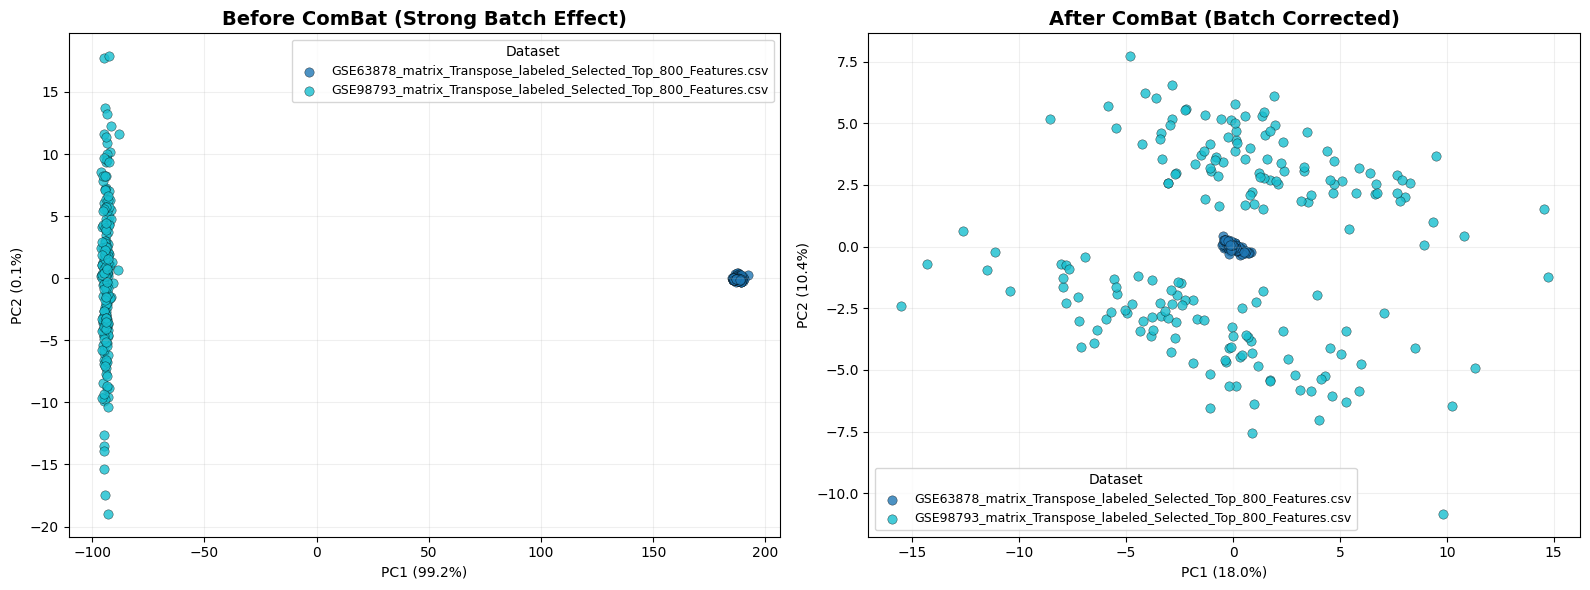

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# PCA FUNCTION (CLEAN + PAPER QUALITY)
# =========================
def plot_pca(data, batch, title, ax):

    # PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(data)

    batch = pd.Series(batch).reset_index(drop=True)

    unique_batches = batch.unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_batches)))

    for color, b in zip(colors, unique_batches):
        idx = batch == b

        ax.scatter(
            reduced[idx, 0],
            reduced[idx, 1],
            color=color,
            label=b.replace("_matrix_Transpose_labeled.csv", ""),
            alpha=0.8,
            s=45,
            edgecolor="black",
            linewidth=0.3
        )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(title="Dataset", fontsize=9)
    ax.grid(alpha=0.2)


# =========================
# DATA PREPARATION
# =========================

# Before ComBat
expr_before = X.copy()

# After ComBat
expr_after = final_df.drop(columns=["target", "Batch"])

# Batch labels
batch_labels = final_df["Batch"].reset_index(drop=True)

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_pca(
    expr_before,
    batch_labels,
    "Before ComBat (Strong Batch Effect)",
    axes[0]
)

plot_pca(
    expr_after,
    batch_labels,
    "After ComBat (Batch Corrected)",
    axes[1]
)

plt.tight_layout()

# =========================
# SAVE HIGH-QUALITY FIGURE
# =========================
plt.savefig(
    "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/PCA_Before_After_ComBat.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

🔥 Silhouette Before: 0.9602
✅ Silhouette After: 0.0234
🔥 Variance Before: 25.057325362729976
✅ Variance After: 8.463261179023439e-09
📉 Reduction %: 99.99999996622441


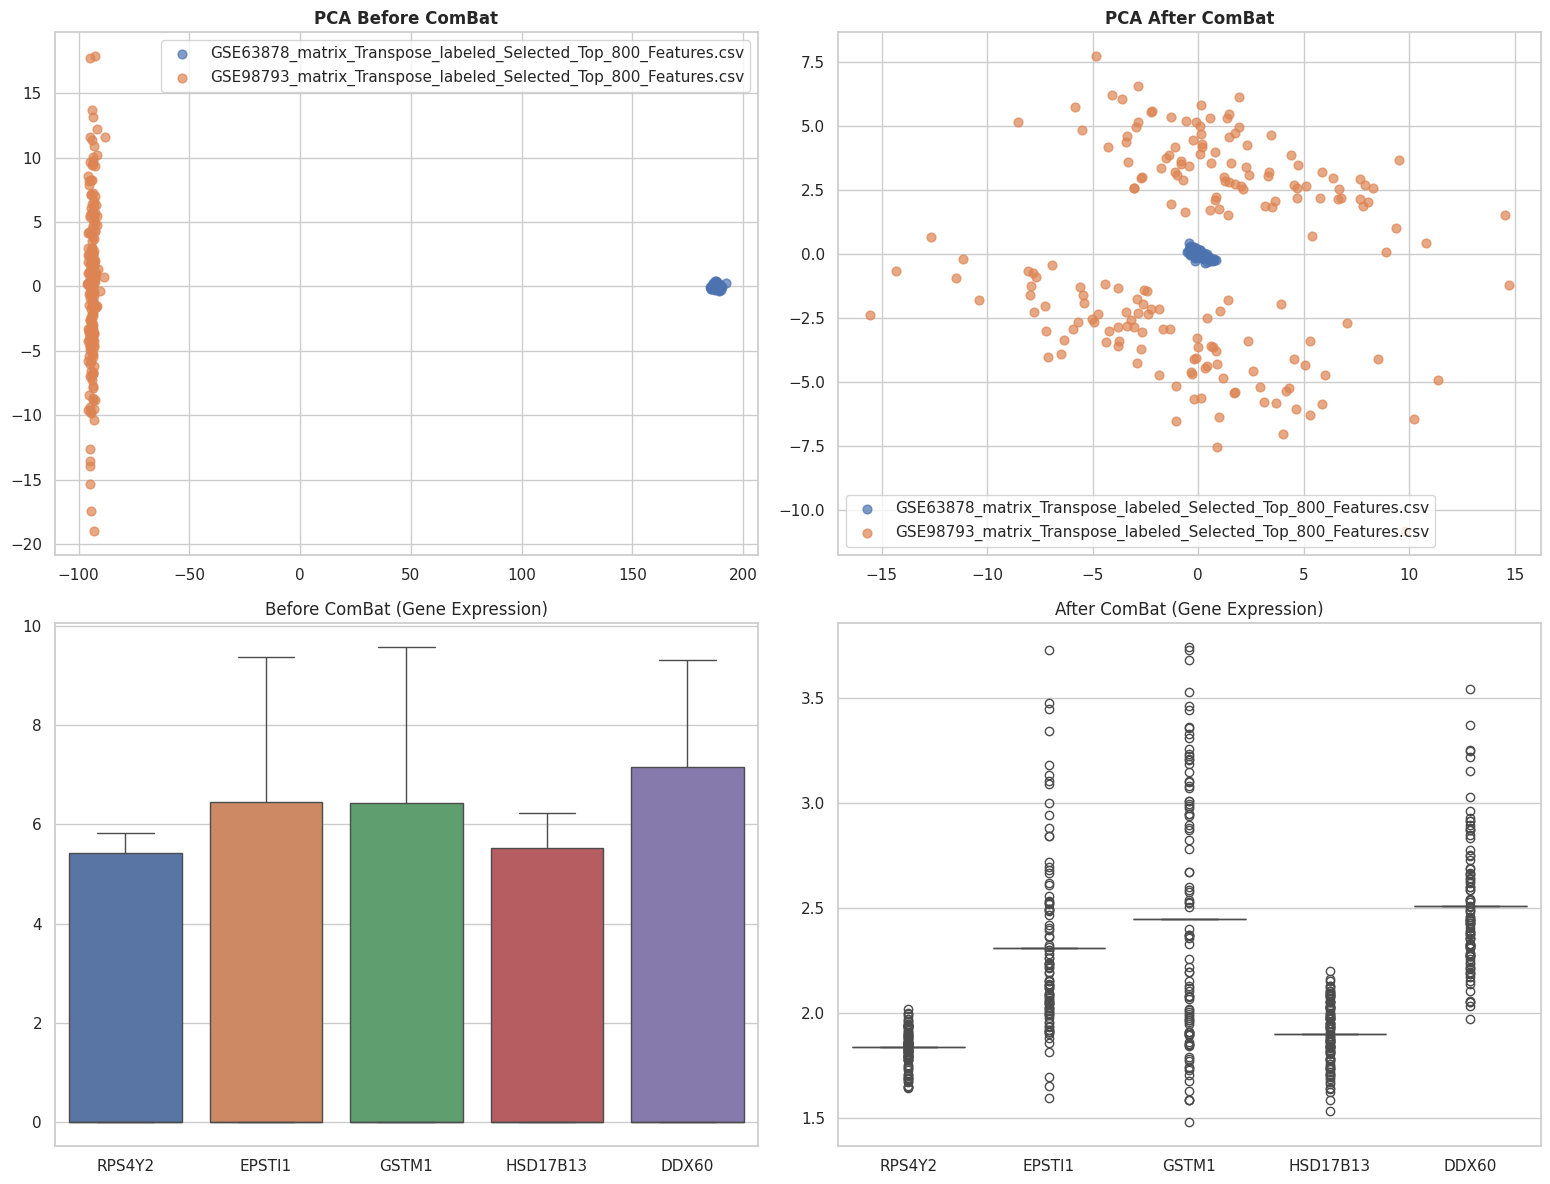

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

# =========================
# DATA
# =========================
expr_before = X.copy()
expr_after = final_df.drop(columns=["target", "Batch"])
batch_labels = final_df["Batch"].reset_index(drop=True)
batch_numeric = pd.factorize(batch_labels)[0]

genes = expr_before.columns[:5]  # sample genes

# =========================
# PCA FUNCTION
# =========================
def pca_plot(data, batch, ax, title):
    pca = PCA(n_components=2)
    emb = pca.fit_transform(data)

    for b in np.unique(batch):
        idx = batch == b
        ax.scatter(
            emb[idx, 0],
            emb[idx, 1],
            label=str(b).replace("_matrix_Transpose_labeled.csv", ""),
            alpha=0.7,
            s=40
        )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend()

# =========================
# FIGURE LAYOUT
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# -------------------------
# PCA BEFORE / AFTER
# -------------------------
pca_plot(expr_before, batch_labels, axes[0,0], "PCA Before ComBat")
pca_plot(expr_after, batch_labels, axes[0,1], "PCA After ComBat")

# -------------------------
# BOXPLOT BEFORE / AFTER
# -------------------------
sns.boxplot(data=expr_before[genes], ax=axes[1,0])
axes[1,0].set_title("Before ComBat (Gene Expression)")

sns.boxplot(data=expr_after[genes], ax=axes[1,1])
axes[1,1].set_title("After ComBat (Gene Expression)")

plt.tight_layout()

# =========================
# METRICS
# =========================
before_emb = PCA(n_components=10).fit_transform(expr_before)
after_emb = PCA(n_components=10).fit_transform(expr_after)

before_sil = silhouette_score(before_emb, batch_numeric)
after_sil = silhouette_score(after_emb, batch_numeric)

before_var = expr_before.groupby(batch_labels).mean().var().mean()
after_var = expr_after.groupby(batch_labels).mean().var().mean()

print("🔥 Silhouette Before:", round(before_sil, 4))
print("✅ Silhouette After:", round(after_sil, 4))

print("🔥 Variance Before:", before_var)
print("✅ Variance After:", after_var)
print("📉 Reduction %:", ((before_var - after_var)/before_var)*100)

# =========================
# SAVE FIGURE
# =========================
plt.savefig(
    "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/ComBat_Validation_Panel.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

#Before vs After ComBat (PCA Figure)

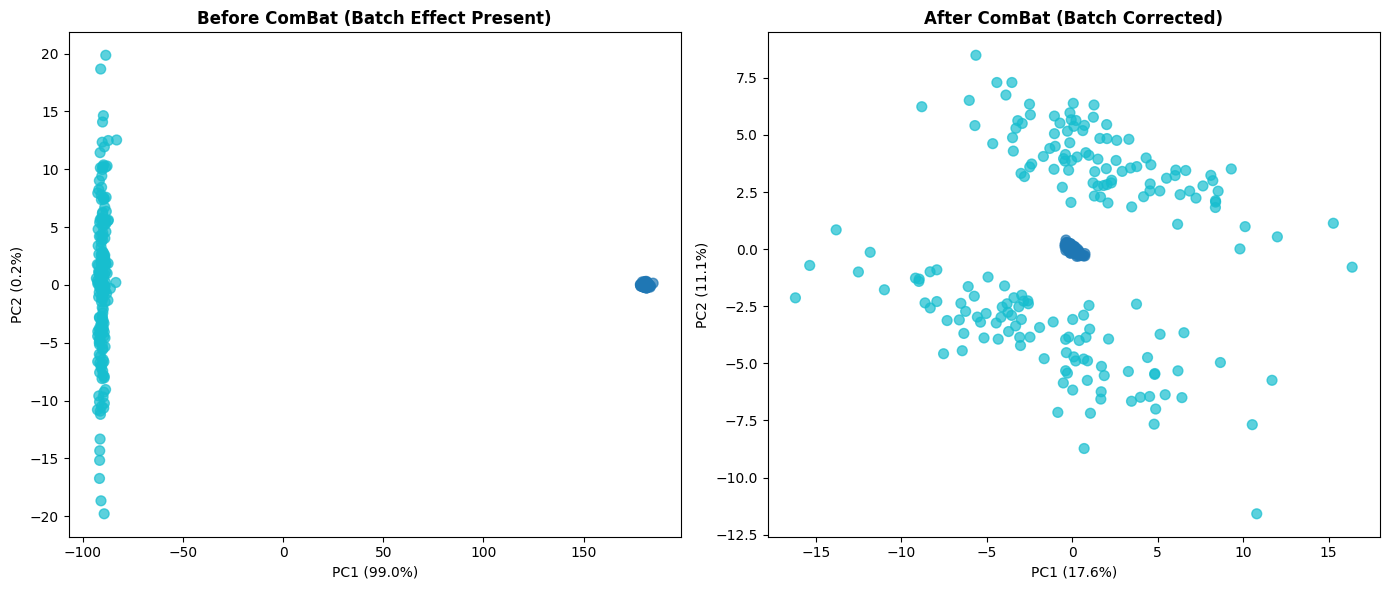

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# PCA FUNCTION
# =========================
def plot_pca(data, batch, title, ax):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(data)

    scatter = ax.scatter(
        reduced[:, 0],
        reduced[:, 1],
        c=pd.factorize(batch)[0],
        cmap="tab10",
        alpha=0.7,
        s=50
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
    )
    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
    )

# =========================
# DATA FOR PCA
# =========================

# BEFORE ComBat
expr_before = X.copy()

# AFTER ComBat
expr_after = final_df.drop(columns=["target", "Batch"])

# Batch labels
batch_labels = final_df["Batch"]

# =========================
# FIGURE SETUP
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BEFORE ComBat
plot_pca(
    expr_before,
    batch_labels,
    "Before ComBat (Batch Effect Present)",
    axes[0]
)

# AFTER ComBat
plot_pca(
    expr_after,
    batch_labels,
    "After ComBat (Batch Corrected)",
    axes[1]
)

plt.tight_layout()
plt.show()

#Batch Effect Quantification Score (Before vs After)

In [11]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# =========================
# FUNCTION: PCA embedding
# =========================
def get_embedding(data):
    pca = PCA(n_components=10, random_state=42)
    return pca.fit_transform(data)

# =========================
# DATA PREPARATION
# =========================

# BEFORE ComBat
expr_before = X.copy()

# AFTER ComBat
expr_after = final_df.drop(columns=["target", "Batch"])

# Batch labels (same for both)
batch_labels = final_df["Batch"].reset_index(drop=True)
batch_numeric = pd.factorize(batch_labels)[0]

# =========================
# EMBEDDING
# =========================

before_emb = get_embedding(expr_before)
after_emb = get_embedding(expr_after)

# =========================
# SILHOUETTE SCORE
# (lower = better mixing = less batch effect)
# =========================

before_score = silhouette_score(before_emb, batch_numeric)
after_score = silhouette_score(after_emb, batch_numeric)

# =========================
# RESULTS
# =========================
print("🔥 Batch Effect Score (Before ComBat):", round(before_score, 4))
print("✅ Batch Effect Score (After ComBat):", round(after_score, 4))

if after_score < before_score:
    print("🎯 Batch effect reduced after ComBat ✔️")
else:
    print("⚠️ Warning: Batch effect not properly corrected")

🔥 Batch Effect Score (Before ComBat): 0.957
✅ Batch Effect Score (After ComBat): 0.0335
🎯 Batch effect reduced after ComBat ✔️


#Common genes

                                         Combination  Genes
0  GSE63878\nStress\nTop800 + GSE98793\nDepressio...     19
1       GSE63878\nStress\nTop800 + ComBat\nCorrected    800
2   GSE98793\nDepression\nTop800 + ComBat\nCorrected    800
3                                     All Three Sets     19
Saved: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/Common_Gene_Analysis/Gene_Set_Intersection_Table.csv


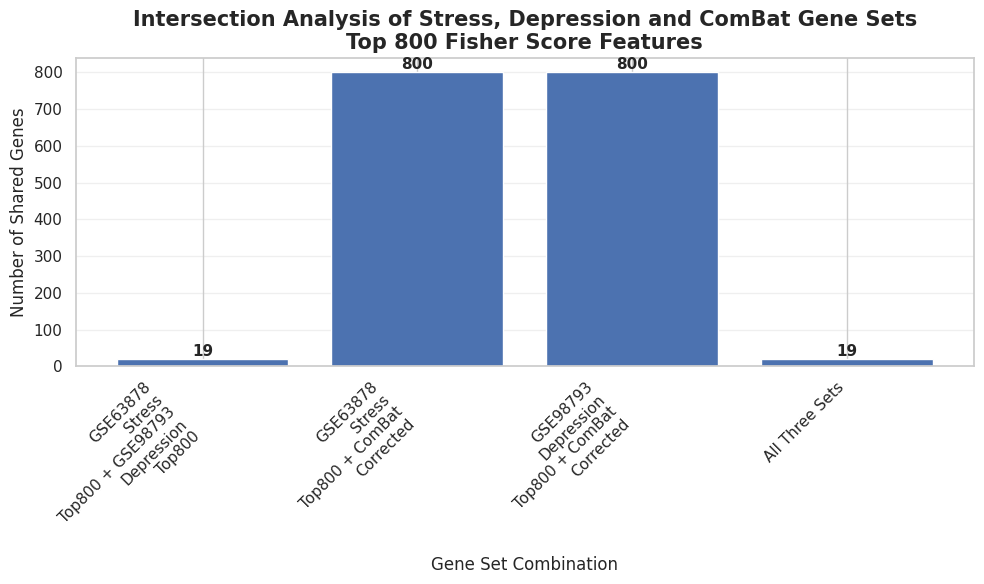

Figure saved: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/Common_Gene_Analysis/Intersection_Analysis_Top800.png


In [21]:
# ==========================================================
# Stable UpSet-like Intersection Plot
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd
import os


# Gene set dictionary

gene_sets = {

    "GSE63878\nStress\nTop800":
        GSE63878_set,


    "GSE98793\nDepression\nTop800":
        GSE98793_set,


    "ComBat\nCorrected":
        combat_set
}



# ==========================================================
# Calculate intersections
# ==========================================================


intersection_data = []


names = list(gene_sets.keys())


for i in range(len(names)):

    for j in range(i+1, len(names)):

        inter = (
            gene_sets[names[i]]
            &
            gene_sets[names[j]]
        )

        intersection_data.append({

            "Combination":
            names[i]+" + "+names[j],

            "Genes":
            len(inter)

        })



# Three-way intersection

three_way = (
    GSE63878_set
    &
    GSE98793_set
    &
    combat_set
)


intersection_data.append({

    "Combination":
    "All Three Sets",

    "Genes":
    len(three_way)

})



intersection_df = pd.DataFrame(
    intersection_data
)



print(intersection_df)



# Save table

intersection_csv = (
    f"{output_dir}/Gene_Set_Intersection_Table.csv"
)


intersection_df.to_csv(
    intersection_csv,
    index=False
)


print(
    "Saved:",
    intersection_csv
)



# ==========================================================
# Plot
# ==========================================================


plt.figure(
    figsize=(10,6)
)



bars = plt.bar(
    intersection_df["Combination"],
    intersection_df["Genes"]
)



plt.xticks(
    rotation=45,
    ha="right"
)



plt.ylabel(
    "Number of Shared Genes",
    fontsize=12
)



plt.xlabel(
    "Gene Set Combination",
    fontsize=12
)



plt.title(
    "Intersection Analysis of Stress, Depression and ComBat Gene Sets\nTop 800 Fisher Score Features",
    fontsize=15,
    fontweight="bold"
)



# Add value labels

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )



plt.grid(
    axis="y",
    alpha=0.3
)



plt.tight_layout()



intersection_fig = (
    f"{output_dir}/Intersection_Analysis_Top800.png"
)



plt.savefig(
    intersection_fig,
    dpi=1000,
    bbox_inches="tight"
)



plt.show()



print(
    "Figure saved:",
    intersection_fig
)

#1000_selection gene

In [22]:
import pandas as pd
import os

# =========================
# FUNCTION (MUST RUN FIRST)
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)

    # clean column names
    df.columns = df.columns.str.strip()

    # get all columns except target
    genes = (
        pd.Index(df.columns)
        .str.upper()
        .str.strip()
    )

    # remove Sample and target columns if present
    genes = genes.difference(["SAMPLE", "TARGET"])

    return set(genes)


# =========================
# COMMON GENE PIPELINE
# =========================
base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection"

datasets = [
    "GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv",
    "GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
]

# datasets = [
#     "GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv",
#     "GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
# ]

# datasets = [
#     "GSE63878_matrix_Transpose_labeled_Selected_Top_500_Features.csv",
#     "GSE98793_matrix_Transpose_labeled_Selected_Top_500_Features.csv"
# ]


gene_sets = []

for ds in datasets:
    path = os.path.join(base_path, ds)

    genes = get_gene_set(path)

    print(ds, "genes:", len(genes))
    gene_sets.append(genes)

# =========================
# FIND COMMON GENES
# =========================
common_genes = set.intersection(*gene_sets)

print("\n✅ FINAL COMMON GENES:", len(common_genes))

# =========================
# SAVE COMMON GENES
# =========================
common_genes_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Gene.symbol"]
)

output_file = os.path.join(base_path, "Common_Genes.csv")
common_genes_df.to_csv(output_file, index=False)

print("✅ Common genes saved to:", output_file)

GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv genes: 858
GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv genes: 1000

✅ FINAL COMMON GENES: 27
✅ Common genes saved to: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/Common_Genes.csv


In [33]:
import pandas as pd


# ==========================================================
# File paths
# ==========================================================

base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection"


GSE63878_file = (
    f"{base_path}/GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
)


GSE98793_file = (
    f"{base_path}/GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
)



# ==========================================================
# Load datasets
# ==========================================================


GSE63878_df = pd.read_csv(
    GSE63878_file
)


GSE98793_df = pd.read_csv(
    GSE98793_file
)



# ==========================================================
# Extract gene sets
# (last column is target/class, exclude it)
# ==========================================================


top1000_GSE63878 = set(
    GSE63878_df.columns[:-1]
)


top1000_GSE98793 = set(
    GSE98793_df.columns[:-1]
)



# ==========================================================
# Common genes
# ==========================================================


common_genes = list(
    top1000_GSE63878
    .intersection(top1000_GSE98793)
)



# ==========================================================
# Result
# ==========================================================


print(
    "Number of Common Genes =",
    len(common_genes)
)


print(
    "\nCommon Genes:\n"
)



for gene in sorted(common_genes):

    print(gene)



# ==========================================================
# Save common genes
# ==========================================================


common_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Common_Gene"]
)



output_file = (
    f"{base_path}/Common_Genes_GSE63878_GSE98793_Top1000.csv"
)



common_df.to_csv(
    output_file,
    index=False
)



print(
    "\nSaved:",
    output_file
)

Number of Common Genes = 27

Common Genes:

AHI1
BARD1
BTN3A2
CCDC57
CYP2U1
DDX60L
DKKL1
DOCK4
EIF4B
FCER1A
GALNT11
GFI1B
GRB10
HGF
HTRA1
IGF1R
OLFM4
PLXNA2
PML
PTMA
SCAPER
SLC22A14
STAT2
SYTL2
TDRD9
TGIF1
TIGIT

Saved: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/Common_Genes_GSE63878_GSE98793_Top1000.csv


#800_selection_gene

In [24]:
import pandas as pd
import os

# =========================
# FUNCTION (MUST RUN FIRST)
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)

    # clean column names
    df.columns = df.columns.str.strip()

    # get all columns except target
    genes = (
        pd.Index(df.columns)
        .str.upper()
        .str.strip()
    )

    # remove Sample and target columns if present
    genes = genes.difference(["SAMPLE", "TARGET"])

    return set(genes)


# =========================
# COMMON GENE PIPELINE
# =========================
base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection"

# datasets = [
#     "GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv",
#     "GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
# ]

datasets = [
    "GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv",
    "GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
]

# datasets = [
#     "GSE63878_matrix_Transpose_labeled_Selected_Top_500_Features.csv",
#     "GSE98793_matrix_Transpose_labeled_Selected_Top_500_Features.csv"
# ]


gene_sets = []

for ds in datasets:
    path = os.path.join(base_path, ds)

    genes = get_gene_set(path)

    print(ds, "genes:", len(genes))
    gene_sets.append(genes)

# =========================
# FIND COMMON GENES
# =========================
common_genes = set.intersection(*gene_sets)

print("\n✅ FINAL COMMON GENES:", len(common_genes))

# =========================
# SAVE COMMON GENES
# =========================
common_genes_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Gene.symbol"]
)

output_file = os.path.join(base_path, "Common_Genes.csv")
common_genes_df.to_csv(output_file, index=False)

print("✅ Common genes saved to:", output_file)

GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv genes: 800
GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv genes: 800

✅ FINAL COMMON GENES: 19
✅ Common genes saved to: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/Common_Genes.csv


In [34]:
import pandas as pd


# ==========================================================
# File paths
# ==========================================================

base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection"


GSE63878_file = (
    f"{base_path}/GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
)


GSE98793_file = (
    f"{base_path}/GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
)



# ==========================================================
# Load datasets
# ==========================================================


GSE63878_df = pd.read_csv(
    GSE63878_file
)


GSE98793_df = pd.read_csv(
    GSE98793_file
)



# ==========================================================
# Extract gene sets
# (last column is target/class, exclude it)
# ==========================================================


top1000_GSE63878 = set(
    GSE63878_df.columns[:-1]
)


top1000_GSE98793 = set(
    GSE98793_df.columns[:-1]
)



# ==========================================================
# Common genes
# ==========================================================


common_genes = list(
    top1000_GSE63878
    .intersection(top1000_GSE98793)
)



# ==========================================================
# Result
# ==========================================================


print(
    "Number of Common Genes =",
    len(common_genes)
)


print(
    "\nCommon Genes:\n"
)



for gene in sorted(common_genes):

    print(gene)



# ==========================================================
# Save common genes
# ==========================================================


common_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Common_Gene"]
)



output_file = (
    f"{base_path}/Common_Genes_GSE63878_GSE98793_Top1000.csv"
)



common_df.to_csv(
    output_file,
    index=False
)



print(
    "\nSaved:",
    output_file
)

Number of Common Genes = 19

Common Genes:

AHI1
BTN3A2
CYP2U1
DKKL1
DOCK4
EIF4B
GALNT11
GFI1B
HGF
IGF1R
OLFM4
PLXNA2
PML
PTMA
SCAPER
SLC22A14
STAT2
SYTL2
TDRD9

Saved: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/Common_Genes_GSE63878_GSE98793_Top1000.csv


#500_selection Gene

In [25]:
import pandas as pd
import os

# =========================
# FUNCTION (MUST RUN FIRST)
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)

    # clean column names
    df.columns = df.columns.str.strip()

    # get all columns except target
    genes = (
        pd.Index(df.columns)
        .str.upper()
        .str.strip()
    )

    # remove Sample and target columns if present
    genes = genes.difference(["SAMPLE", "TARGET"])

    return set(genes)


# =========================
# COMMON GENE PIPELINE
# =========================
base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection"

# datasets = [
#     "GSE63878_matrix_Transpose_labeled_Selected_Top_1000_Features.csv",
#     "GSE98793_matrix_Transpose_labeled_Selected_Top_1000_Features.csv"
# ]

# datasets = [
#     "GSE63878_matrix_Transpose_labeled_Selected_Top_800_Features.csv",
#     "GSE98793_matrix_Transpose_labeled_Selected_Top_800_Features.csv"
# ]

datasets = [
    "GSE63878_matrix_Transpose_labeled_Selected_Top_500_Features.csv",
    "GSE98793_matrix_Transpose_labeled_Selected_Top_500_Features.csv"
]


gene_sets = []

for ds in datasets:
    path = os.path.join(base_path, ds)

    genes = get_gene_set(path)

    print(ds, "genes:", len(genes))
    gene_sets.append(genes)

# =========================
# FIND COMMON GENES
# =========================
common_genes = set.intersection(*gene_sets)

print("\n✅ FINAL COMMON GENES:", len(common_genes))

# =========================
# SAVE COMMON GENES
# =========================
common_genes_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Gene.symbol"]
)

output_file = os.path.join(base_path, "Common_Genes.csv")
common_genes_df.to_csv(output_file, index=False)

print("✅ Common genes saved to:", output_file)

GSE63878_matrix_Transpose_labeled_Selected_Top_500_Features.csv genes: 500
GSE98793_matrix_Transpose_labeled_Selected_Top_500_Features.csv genes: 500

✅ FINAL COMMON GENES: 6
✅ Common genes saved to: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/Common_Genes.csv


In [35]:
import pandas as pd


# ==========================================================
# File paths
# ==========================================================

base_path = "/content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection"


GSE63878_file = (
    f"{base_path}/GSE63878_matrix_Transpose_labeled_Selected_Top_500_Features.csv"
)


GSE98793_file = (
    f"{base_path}/GSE98793_matrix_Transpose_labeled_Selected_Top_500_Features.csv"
)



# ==========================================================
# Load datasets
# ==========================================================


GSE63878_df = pd.read_csv(
    GSE63878_file
)


GSE98793_df = pd.read_csv(
    GSE98793_file
)



# ==========================================================
# Extract gene sets
# (last column is target/class, exclude it)
# ==========================================================


top1000_GSE63878 = set(
    GSE63878_df.columns[:-1]
)


top1000_GSE98793 = set(
    GSE98793_df.columns[:-1]
)



# ==========================================================
# Common genes
# ==========================================================


common_genes = list(
    top1000_GSE63878
    .intersection(top1000_GSE98793)
)



# ==========================================================
# Result
# ==========================================================


print(
    "Number of Common Genes =",
    len(common_genes)
)


print(
    "\nCommon Genes:\n"
)



for gene in sorted(common_genes):

    print(gene)



# ==========================================================
# Save common genes
# ==========================================================


common_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Common_Gene"]
)



output_file = (
    f"{base_path}/Common_Genes_GSE63878_GSE98793_Top1000.csv"
)



common_df.to_csv(
    output_file,
    index=False
)



print(
    "\nSaved:",
    output_file
)

Number of Common Genes = 6

Common Genes:

EIF4B
GALNT11
OLFM4
PML
SYTL2
TDRD9

Saved: /content/drive/MyDrive/p5_stress_depression_journal/process_datasets_0.08/selection/Common_Genes_GSE63878_GSE98793_Top1000.csv
